# 🌸 Training Model CNN — Klasifikasi Jenis Bunga

Notebook ini digunakan untuk melatih model **Convolutional Neural Network (CNN)** yang dapat mengklasifikasikan 5 jenis bunga:
- Daisy
- Dandelion
- Rose
- Sunflower
- Tulip

**Dataset**: [Flowers Recognition — Kaggle](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition)

**Framework**: TensorFlow / Keras

## 1. Import Library

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import json
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.16.1
GPU available: False


## 2. Konfigurasi

In [2]:
DATASET_PATH = "Data/flowers"
MODEL_PATH = "models/flower_model.h5"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15

# Buat folder models
os.makedirs("models", exist_ok=True)

print(f"Dataset Path : {DATASET_PATH}")
print(f"Model Path   : {MODEL_PATH}")
print(f"Image Size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")

Dataset Path : Data/flowers
Model Path   : models/flower_model.h5
Image Size   : 128x128
Batch Size   : 32
Epochs       : 15


## 3. Data Augmentation & Loading

Menggunakan `ImageDataGenerator` untuk:
- **Rescale** pixel values ke range [0, 1]
- **Split** data menjadi 80% training dan 20% validasi
- **Augmentasi**: rotasi, zoom, shift, dan flip horizontal

In [3]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

print("ImageDataGenerator berhasil dibuat.")

ImageDataGenerator berhasil dibuat.


In [4]:
# Data Training
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Data Validasi
validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(f"\nJumlah data training  : {train_generator.samples}")
print(f"Jumlah data validasi  : {validation_generator.samples}")

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Jumlah data training  : 3457
Jumlah data validasi  : 860


## 4. Simpan Nama Kelas

In [5]:
class_names = list(train_generator.class_indices.keys())

with open("models/class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Kelas yang ditemukan:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Kelas yang ditemukan:
  0: daisy
  1: dandelion
  2: rose
  3: sunflower
  4: tulip


## 5. Visualisasi Sampel Dataset

Menampilkan beberapa contoh gambar dari dataset training.

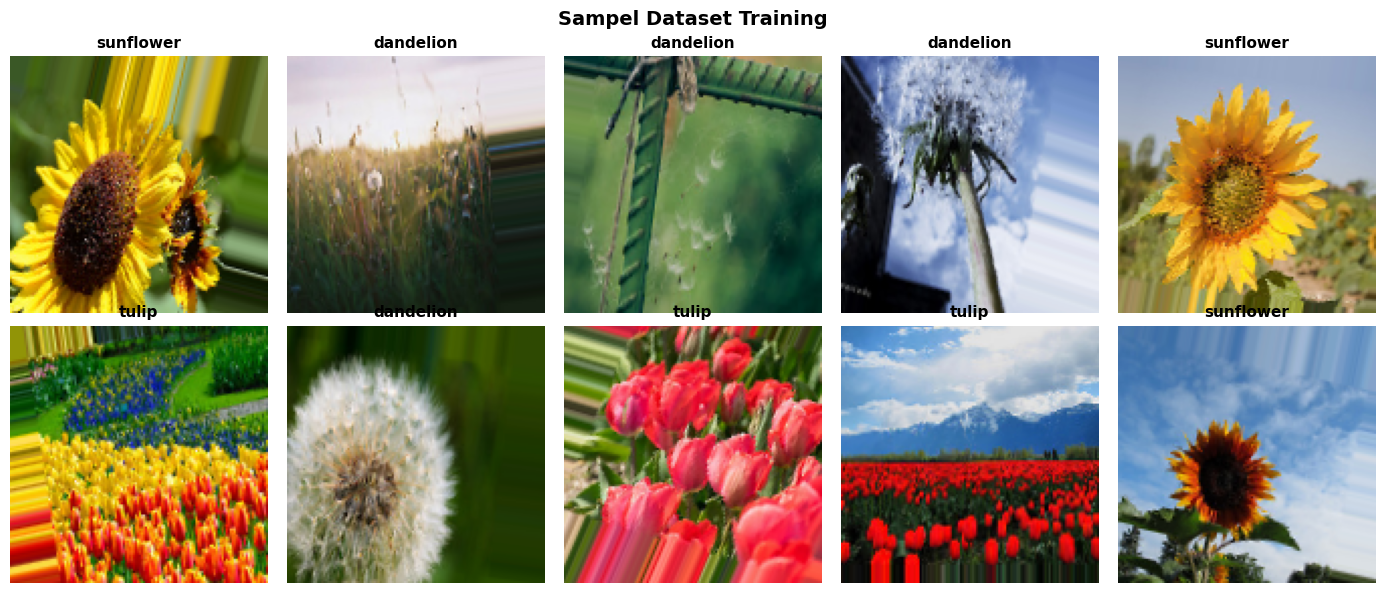

In [6]:
# Ambil satu batch dari training data
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    label_index = np.argmax(sample_labels[i])
    plt.title(class_names[label_index], fontsize=11, fontweight="bold")
    plt.axis("off")

plt.suptitle("Sampel Dataset Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Arsitektur Model CNN

Model terdiri dari:
- 3 lapisan **Conv2D** + **MaxPooling2D** untuk ekstraksi fitur
- **Flatten** untuk mengubah matriks menjadi vektor
- **Dense** layer untuk klasifikasi
- **Dropout** (0.5) untuk mencegah overfitting
- **Softmax** untuk output probabilitas multi-kelas

In [7]:
model = Sequential([

    # Layer Konvolusi 1
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    # Layer Konvolusi 2
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Layer Konvolusi 3
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(256, activation="relu"),

    # Dropout untuk regularisasi
    Dropout(0.5),

    # Output Layer
    Dense(len(class_names), activation="softmax")

])

print("Model CNN berhasil dibuat.")

Model CNN berhasil dibuat.


c:\Users\Brt_com\Downloads\flower-cnn-flask\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 7. Compile Model

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Callbacks

- **ModelCheckpoint**: Menyimpan model terbaik berdasarkan `val_accuracy`
- **EarlyStopping**: Menghentikan training jika `val_loss` tidak membaik selama 5 epoch

In [9]:
checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Callbacks berhasil dikonfigurasi.")

Callbacks berhasil dikonfigurasi.


## 9. Training Model

In [10]:
print("Memulai training model...\n")

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

print("\nTraining selesai!")

Memulai training model...

Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3497 - loss: 1.4864
Epoch 1: val_accuracy improved from None to 0.54767, saving model to models/flower_model.h5



Epoch 1: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 334ms/step - accuracy: 0.4275 - loss: 1.3183 - val_accuracy: 0.5477 - val_loss: 1.1187
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5438 - loss: 1.1393
Epoch 2: val_accuracy improved from 0.54767 to 0.56395, saving model to models/flower_model.h5



Epoch 2: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 303ms/step - accuracy: 0.5701 - loss: 1.0845 - val_accuracy: 0.5640 - val_loss: 1.0650
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5964 - loss: 1.0236
Epoch 3: val_accuracy improved from 0.56395 to 0.64884, saving model to models/flower_model.h5



Epoch 3: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.6112 - loss: 0.9959 - val_accuracy: 0.6488 - val_loss: 0.9334
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.6315 - loss: 0.9278
Epoch 4: val_accuracy did not improve from 0.64884
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.6364 - loss: 0.9284 - val_accuracy: 0.6326 - val_loss: 0.9616
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6343 - loss: 0.9271
Epoch 5: val_accuracy improved from 0.64884 to 0.65233, saving model to models/flower_model.h5



Epoch 5: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 312ms/step - accuracy: 0.6303 - loss: 0.9322 - val_accuracy: 0.6523 - val_loss: 0.8992
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.6506 - loss: 0.8685
Epoch 6: val_accuracy improved from 0.65233 to 0.67674, saving model to models/flower_model.h5



Epoch 6: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 311ms/step - accuracy: 0.6598 - loss: 0.8889 - val_accuracy: 0.6767 - val_loss: 0.8299
Epoch 7/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6538 - loss: 0.8930
Epoch 7: val_accuracy improved from 0.67674 to 0.68140, saving model to models/flower_model.h5



Epoch 7: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 309ms/step - accuracy: 0.6555 - loss: 0.8893 - val_accuracy: 0.6814 - val_loss: 0.8210
Epoch 8/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6702 - loss: 0.8393
Epoch 8: val_accuracy improved from 0.68140 to 0.71279, saving model to models/flower_model.h5



Epoch 8: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 309ms/step - accuracy: 0.6772 - loss: 0.8336 - val_accuracy: 0.7128 - val_loss: 0.8006
Epoch 9/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6942 - loss: 0.7775
Epoch 9: val_accuracy did not improve from 0.71279
109/109 ━━━━━━━━━━━━━━━━━━━━ 43s 396ms/step - accuracy: 0.6861 - loss: 0.7993 - val_accuracy: 0.7058 - val_loss: 0.8160
Epoch 10/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7106 - loss: 0.7774
Epoch 10: val_accuracy did not improve from 0.71279
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 300ms/step - accuracy: 0.6977 - loss: 0.7932 - val_accuracy: 0.6698 - val_loss: 0.7937
Epoch 11/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.7066 - loss: 0.7848
Epoch 11: val_accuracy did not improve from 0.71279
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 310ms/step - accuracy: 0.7168 - loss: 0.7609 - val_accuracy: 0.6965 - val_loss: 0.7812
Epoch 12/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 14: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 308ms/step - accuracy: 0.7342 - loss: 0.7093 - val_accuracy: 0.7291 - val_loss: 0.7567
Epoch 15/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7234 - loss: 0.7255
Epoch 15: val_accuracy improved from 0.72907 to 0.73953, saving model to models/flower_model.h5



Epoch 15: finished saving model to models/flower_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 307ms/step - accuracy: 0.7266 - loss: 0.7113 - val_accuracy: 0.7395 - val_loss: 0.6937

Training selesai!


## 10. Evaluasi Model

In [11]:
loss, accuracy = model.evaluate(validation_generator)

print(f"\n{'='*40}")
print(f"AKURASI VALIDASI : {accuracy * 100:.2f}%")
print(f"LOSS VALIDASI    : {loss:.4f}")
print(f"{'='*40}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.7058 - loss: 0.7346

AKURASI VALIDASI : 70.58%
LOSS VALIDASI    : 0.7346


## 11. Simpan Training History ke JSON

In [13]:
history_data = {
    "accuracy": [float(x) for x in history.history["accuracy"]],
    "val_accuracy": [float(x) for x in history.history["val_accuracy"]],
    "loss": [float(x) for x in history.history["loss"]],
    "val_loss": [float(x) for x in history.history["val_loss"]],
    "final_accuracy": float(accuracy),
    "final_loss": float(loss)
}

with open("models/training_history.json", "w") as f:
    json.dump(history_data, f, indent=2)

print("Training history disimpan di: models/training_history.json")

Training history disimpan di: models/training_history.json


## 12. Grafik Akurasi & Loss

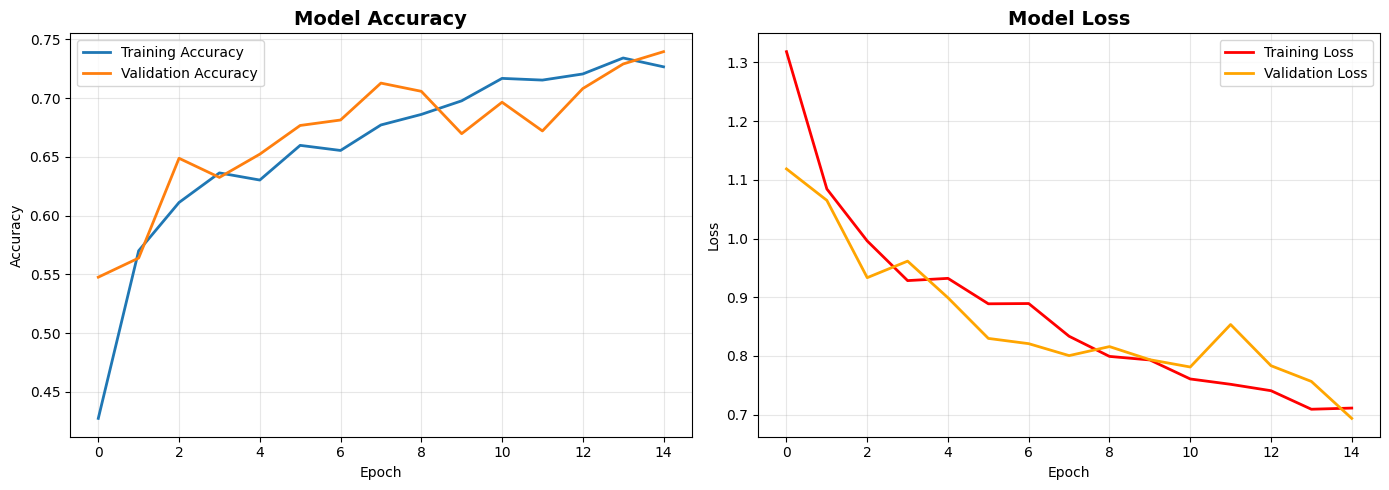

Grafik disimpan di: models/accuracy.png


In [14]:
plt.figure(figsize=(14, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Model Accuracy", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", linewidth=2, color="red")
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2, color="orange")
plt.title("Model Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("models/accuracy.png", dpi=150)
plt.show()

print("Grafik disimpan di: models/accuracy.png")

## 13. Classification Report

In [15]:
# Prediksi pada data validasi
validation_generator.reset()
y_pred_probs = model.predict(validation_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)
print(report)

# Simpan ke file
with open("models/classification_report.txt", "w") as f:
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 50 + "\n\n")
    f.write(report)

print("Classification report disimpan di: models/classification_report.txt")

              precision    recall  f1-score   support

       daisy     0.8943    0.7237    0.8000       152
   dandelion     0.7972    0.8048    0.8009       210
        rose     0.6147    0.4295    0.5057       156
   sunflower     0.8108    0.8219    0.8163       146
       tulip     0.5933    0.8112    0.6853       196

    accuracy                         0.7267       860
   macro avg     0.7421    0.7182    0.7217       860
weighted avg     0.7371    0.7267    0.7235       860

Classification report disimpan di: models/classification_report.txt


## 14. Confusion Matrix

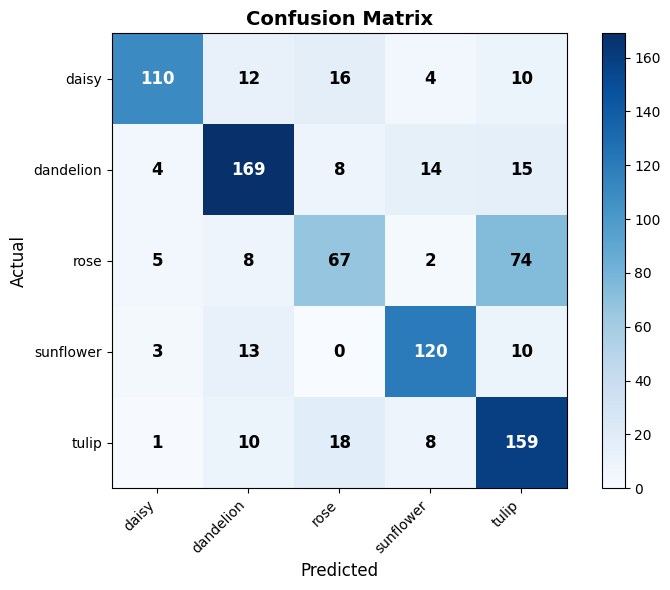

Confusion matrix disimpan di: models/confusion_matrix.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Tampilkan angka di setiap cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=12, fontweight="bold"
        )

plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix disimpan di: models/confusion_matrix.png")

## 15. Ringkasan Hasil Training

File yang dihasilkan:

| No | File | Keterangan |
|----|------|------------|
| 1 | `models/flower_model.h5` | Model CNN yang sudah dilatih |
| 2 | `models/class_names.txt` | Nama kelas bunga |
| 3 | `models/accuracy.png` | Grafik Accuracy & Loss |
| 4 | `models/confusion_matrix.png` | Confusion Matrix |
| 5 | `models/classification_report.txt` | Classification Report |
| 6 | `models/training_history.json` | History Training (JSON) |

In [17]:
print("="*50)
print("TRAINING SELESAI")
print("="*50)
print(f"\nAkurasi Validasi : {accuracy * 100:.2f}%")
print(f"Loss Validasi    : {loss:.4f}")
print(f"Jumlah Epoch     : {len(history.history['accuracy'])}")
print(f"Jumlah Kelas     : {len(class_names)}")
print(f"Kelas            : {class_names}")
print("\nFile yang dihasilkan:")
print("  1. models/flower_model.h5")
print("  2. models/class_names.txt")
print("  3. models/accuracy.png")
print("  4. models/confusion_matrix.png")
print("  5. models/classification_report.txt")
print("  6. models/training_history.json")

TRAINING SELESAI

Akurasi Validasi : 70.58%
Loss Validasi    : 0.7346
Jumlah Epoch     : 15
Jumlah Kelas     : 5
Kelas            : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

File yang dihasilkan:
  1. models/flower_model.h5
  2. models/class_names.txt
  3. models/accuracy.png
  4. models/confusion_matrix.png
  5. models/classification_report.txt
  6. models/training_history.json
